In [1]:
import numpy as np
from utils.lorenz63 import lorenz
from matplotlib import pyplot as plt

In [2]:
times = np.arange(0, 30, 0.01)
xstate, ystate, zstate = 10, 10, 10
rho, beta, sigma = 10, 8.0/3.0, 10.0   #spiral into one of two stable equilibria depending on initial conditions
# rho, beta, sigma = 28.0, 8.0/3.0, 10.0

out = lorenz(time_series=times, init_state=[xstate, ystate, zstate], parameters=[rho, beta, sigma])

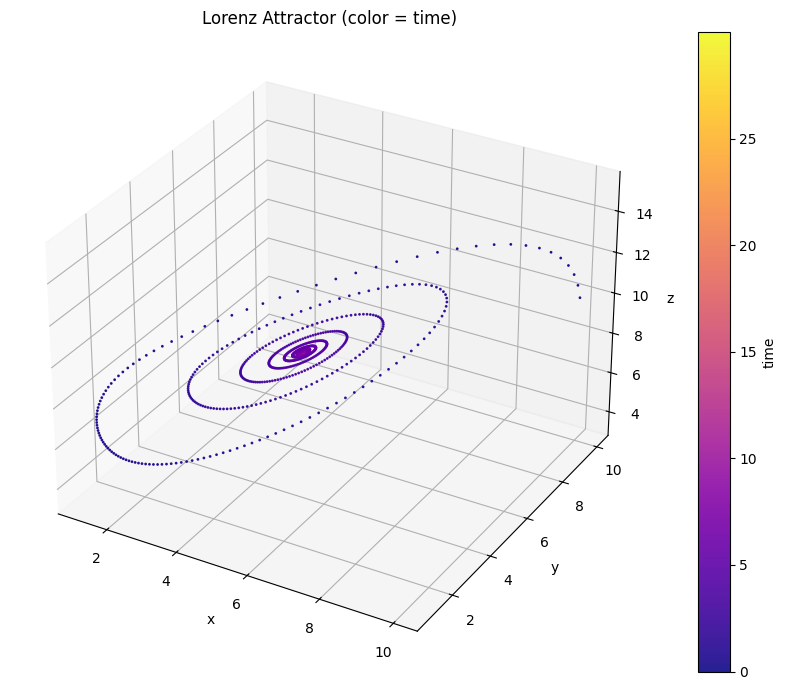

In [3]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')


sc = ax.scatter(
    out[:, 0], out[:, 1], out[:, 2],
    c=times, cmap='plasma', s=1, alpha=0.9
)

ax.set_title("Lorenz Attractor (color = time)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
fig.colorbar(sc, ax=ax, label="time")

plt.tight_layout()
plt.show()

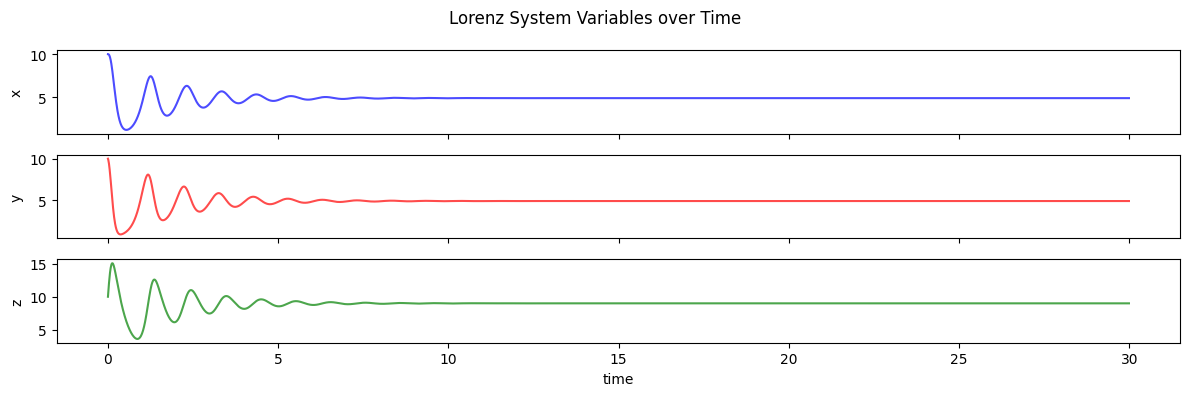

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(12, 4), sharex=True)

axes[0].plot(times, out[:, 0], color='blue', alpha=0.7)
axes[0].set_ylabel("x")

axes[1].plot(times, out[:, 1], color='red', alpha=0.7)
axes[1].set_ylabel("y")

axes[2].plot(times, out[:, 2], color='green', alpha=0.7)
axes[2].set_ylabel("z")
axes[2].set_xlabel("time")

fig.suptitle("Lorenz System Variables over Time")
plt.tight_layout()
plt.show()

In [5]:
# Split the full state into train and test sets
train_size = int(0.8 * len(out))
state_train = out[1000:train_size]
state_test = out[train_size:]

t_train = times[1000:train_size]
t_test = times[train_size:]

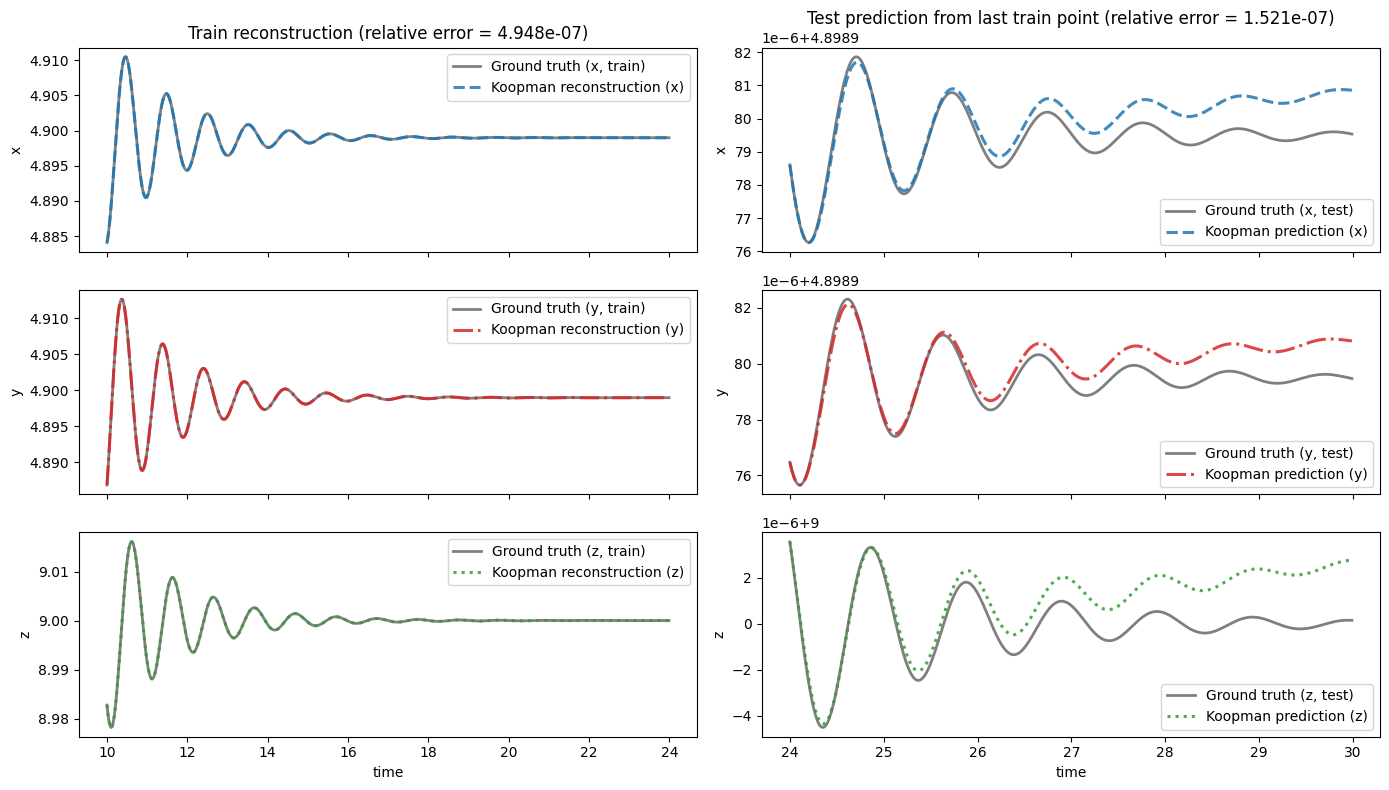

Estimated Koopman eigenvalues: [0.95806893+0.11758771j 0.95806893-0.11758771j 0.99216941+0.06134191j
 0.99216941-0.06134191j 1.        +0.j        ]
Per-state train relative errors: {'x': np.float64(4.985669287547231e-07), 'y': np.float64(5.743397932472217e-07), 'z': np.float64(4.6740296289443314e-07)}
Per-state test relative errors: {'x': np.float64(1.4040005891708084e-07), 'y': np.float64(1.4393449602802628e-07), 'z': np.float64(1.5764561097530129e-07)}


In [6]:
# EDMD/Koopman fit on the full Lorenz state
from utils.koopman import KoopmanEstimator


state_labels = ["x", "y", "z"]
state_colors = ["tab:blue", "tab:red", "tab:green"]
model_linestyles = ["--", "-.", ":"]

koop_model = KoopmanEstimator(
    observable_type="rff",
    degree=3, # only used for polynomial observables
    include_bias=False,
    include_state=True,
    reg=1e-8,
    random_state=0,
)

# Fit K from training snapshots
koop_model.fit(state_train)

# Training reconstruction (rollout from first training point)
state_train_rec = koop_model.reconstruct(state_train[0], n_steps=len(state_train) - 1)

# Test forecast (rollout from last training point)
state_test_pred = koop_model.predict(state_train[-1], steps=len(state_test))[0]

# Relative errors vs ground truth
train_rel_err = np.linalg.norm(state_train_rec - state_train) / np.linalg.norm(state_train)
test_rel_err = np.linalg.norm(state_test_pred - state_test) / np.linalg.norm(state_test)
train_state_rel_err = np.linalg.norm(state_train_rec - state_train, axis=0) / np.linalg.norm(state_train, axis=0)
test_state_rel_err = np.linalg.norm(state_test_pred - state_test, axis=0) / np.linalg.norm(state_test, axis=0)

# Plot reconstructions/predictions against ground truth
fig, axes = plt.subplots(3, 2, figsize=(14, 8), sharex="col")

for idx, (label, color, linestyle) in enumerate(zip(state_labels, state_colors, model_linestyles)):
    axes[idx, 0].plot(
        t_train,
        state_train[:, idx],
        label=f"Ground truth ({label}, train)",
        color="black",
        linewidth=2.0,
        alpha=0.5,
        zorder=1,
    )
    axes[idx, 0].plot(
        t_train,
        state_train_rec[:, idx],
        label=f"Koopman reconstruction ({label})",
        color=color,
        linestyle=linestyle,
        linewidth=2.2,
        alpha=0.85,
        zorder=2,
    )
    axes[idx, 0].set_ylabel(label)
    axes[idx, 0].legend()

    axes[idx, 1].plot(
        t_test,
        state_test[:, idx],
        label=f"Ground truth ({label}, test)",
        color="black",
        linewidth=2.0,
        alpha=0.5,
        zorder=1,
    )
    axes[idx, 1].plot(
        t_test,
        state_test_pred[:, idx],
        label=f"Koopman prediction ({label})",
        color=color,
        linestyle=linestyle,
        linewidth=2.2,
        alpha=0.85,
        zorder=2,
    )
    axes[idx, 1].set_ylabel(label)
    axes[idx, 1].legend()

axes[0, 0].set_title(f"Train reconstruction (relative error = {train_rel_err:.3e})")
axes[0, 1].set_title(f"Test prediction from last train point (relative error = {test_rel_err:.3e})")
axes[-1, 0].set_xlabel("time")
axes[-1, 1].set_xlabel("time")

plt.tight_layout()
plt.show()

K = np.real_if_close(np.linalg.eigvals(koop_model.K_))
print("Estimated Koopman eigenvalues:", K[: min(5, len(K))])
print("Per-state train relative errors:", dict(zip(state_labels, train_state_rel_err)))
print("Per-state test relative errors:", dict(zip(state_labels, test_state_rel_err)))

## Koopman mode decomposition

After fitting $K$, we inspect its eigendecomposition to identify dominant dynamics:
$$
K w_j = \lambda_j w_j.
$$

- $|\lambda_j|$ controls per-step growth/decay.
- $\arg(\lambda_j)$ controls oscillation.
- Continuous-time rates use $\omega_j = \log(\lambda_j)/\Delta t$.

Dynamic modes map spectral coordinates back to physical state through the decoder.
The plots below show: Koopman spectrum, leading mode components, and leading eigenfunction coordinates over time.

K matrix:
[[ 2.73625652e-01  3.23561335e-01  2.36565617e-01 ...  1.13587720e-02
   2.11523052e-02  6.90189329e-03]
 [ 3.42622239e-01  5.26607043e-01  1.16269935e-01 ...  2.07204973e-02
   4.30933057e-04  1.83355823e-02]
 [ 2.07346931e-01  7.89804546e-02  8.04296490e-01 ... -2.26391625e-02
  -9.07178362e-03 -1.09398471e-02]
 ...
 [ 1.22807571e-02  1.97504095e-02 -1.92580369e-02 ...  3.26860491e-03
   2.08300929e-03  6.70756553e-04]
 [ 1.66308221e-02 -6.60578937e-03 -3.12322218e-03 ...  2.29334754e-03
   2.95514379e-02 -1.21744002e-03]
 [ 8.50330020e-03  1.95959192e-02 -1.01244636e-02 ...  8.14884816e-04
  -6.67425666e-04  1.05250965e-03]]

Discrete-time eigenvalues:
[ 1.00000000e+00+0.00000000e+00j  9.92169412e-01-6.13419141e-02j
  9.92169412e-01+6.13419141e-02j  9.78911689e-01+0.00000000e+00j
  9.58068929e-01-1.17587707e-01j  9.58068929e-01+1.17587707e-01j
  1.37045837e-02+0.00000000e+00j  1.68955602e-03+0.00000000e+00j
  1.10072057e-03+0.00000000e+00j -7.73844378e-04+0.00000000e+00j
 

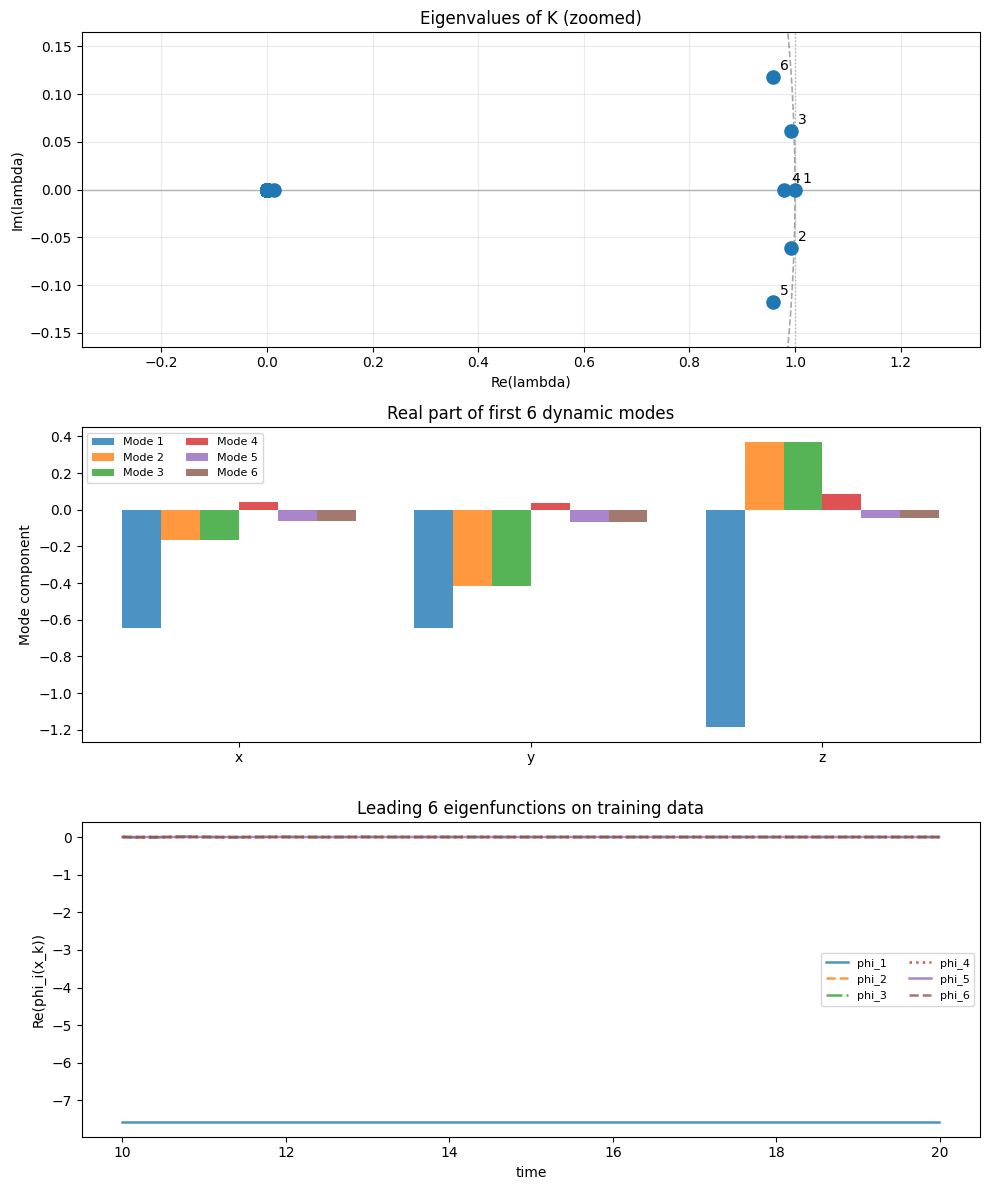

In [7]:
# Spectral analysis of K = koop_model.K_
K = koop_model.K_
eigvals, eigvecs_right = np.linalg.eig(K)
sort_idx = np.argsort(np.abs(eigvals))[::-1]
eigvals = eigvals[sort_idx]
eigvecs_right = eigvecs_right[:, sort_idx]

# Row-wise implementation: psi_{k+1} = psi_k K, with eigenfunction coordinates psi @ v_j
psi_train = koop_model._lift(state_train)
eigenfunction_values = psi_train @ eigvecs_right

# Decoder relation x_hat = psi B = Phi M, where M = V^{-1} B
modal_decoder = np.linalg.solve(eigvecs_right, koop_model.B_)
dynamic_modes = modal_decoder.T
continuous_eigvals = np.log(eigvals) / (times[1] - times[0])
n_modes_plot = min(6, eigvals.shape[0])

print("K matrix:")
print(np.real_if_close(K))
print()
print("Discrete-time eigenvalues:")
print(np.real_if_close(eigvals))
print()
print("Continuous-time eigenvalues:")
print(np.real_if_close(continuous_eigvals))
print()
print(f"Observable dimension: {K.shape[0]}")
print(f"State dimension: {dynamic_modes.shape[0]}")
print()
for mode_idx, lam in enumerate(eigvals[:n_modes_plot], start=1):
    mode = dynamic_modes[:, mode_idx - 1]
    print(f"Mode {mode_idx}: lambda = {lam:.6g}")
    print("  dynamic mode =", np.real_if_close(mode))

fig, axes = plt.subplots(3, 1, figsize=(10, 12))

# Koopman eigenvalues in the complex plane
axes[0].scatter(eigvals.real, eigvals.imag, color="tab:blue", s=90, zorder=3)
for idx, lam in enumerate(eigvals[:n_modes_plot], start=1):
    axes[0].annotate(f"{idx}", (lam.real, lam.imag), textcoords="offset points", xytext=(5, 5))
unit_circle = np.exp(1j * np.linspace(0, 2 * np.pi, 400))
axes[0].plot(unit_circle.real, unit_circle.imag, "k--", alpha=0.35, linewidth=1.2)
axes[0].axhline(0.0, color="0.7", linewidth=1)
axes[0].axvline(1.0, color="0.7", linewidth=1, linestyle=":")
real_pad = max(1e-4, 0.35 * np.ptp(eigvals.real))
imag_pad = max(5e-4, 0.2 * np.ptp(eigvals.imag))
axes[0].set_xlim(eigvals.real.min() - real_pad, eigvals.real.max() + real_pad)
axes[0].set_ylim(eigvals.imag.min() - imag_pad, eigvals.imag.max() + imag_pad)
axes[0].grid(alpha=0.25)
axes[0].set_title("Eigenvalues of K (zoomed)")
axes[0].set_xlabel("Re(lambda)")
axes[0].set_ylabel("Im(lambda)")
axes[0].set_aspect("auto")

# Real part of leading dynamic modes in state coordinates
mode_positions = np.arange(len(state_labels))
bar_width = 0.8 / n_modes_plot
for idx in range(n_modes_plot):
    axes[1].bar(
        mode_positions + idx * bar_width,
        np.real(dynamic_modes[:, idx]),
        width=bar_width,
        label=f"Mode {idx + 1}",
        alpha=0.8,
    )
axes[1].set_xticks(mode_positions + 0.4 - bar_width / 2)
axes[1].set_xticklabels(state_labels)
axes[1].set_title(f"Real part of first {n_modes_plot} dynamic modes")
axes[1].set_ylabel("Mode component")
axes[1].legend(ncol=2, fontsize=8)

# Leading eigenfunction coordinates along the training trajectory
n_plot = min(1000, len(t_train))
eigenfunction_styles = ["-", "--", "-.", ":"]
for idx in range(n_modes_plot):
    axes[2].plot(
        t_train[:n_plot],
        np.real(eigenfunction_values[:n_plot, idx]),
        label=f"phi_{idx + 1}",
        linestyle=eigenfunction_styles[idx % len(eigenfunction_styles)],
        linewidth=1.8,
        alpha=0.8,
    )
axes[2].set_title(f"Leading {n_modes_plot} eigenfunctions on training data")
axes[2].set_xlabel("time")
axes[2].set_ylabel("Re(phi_i(x_k))")
axes[2].legend(ncol=2, fontsize=8)

plt.tight_layout()
plt.show()

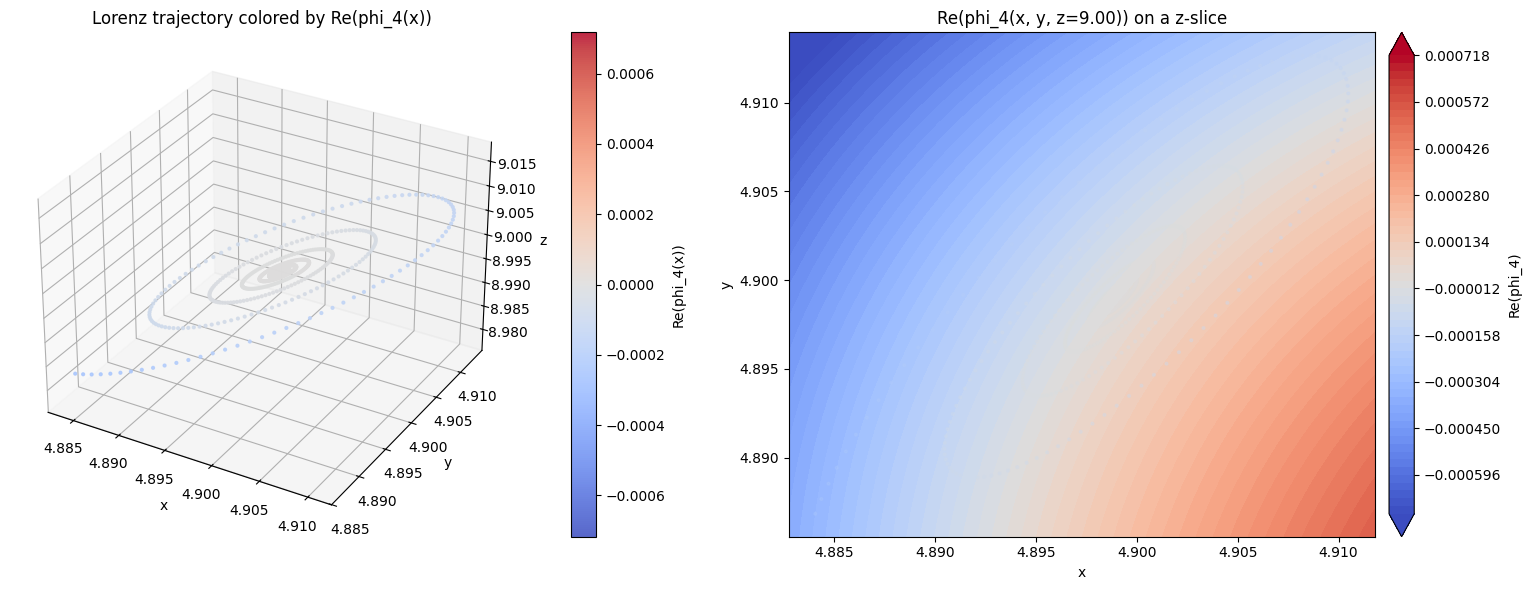

In [10]:
mode_to_plot = min(3, n_modes_plot - 1)

# State-space views of one Koopman eigenfunction phi_j
mode_scores = np.std(np.real(eigenfunction_values[:, :n_modes_plot]), axis=0)
# mode_to_plot = int(np.argmax(mode_scores))
phi_label = f"phi_{mode_to_plot + 1}"
phi_train = np.real(eigenfunction_values[:, mode_to_plot])

fig = plt.figure(figsize=(16, 6))
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax2 = fig.add_subplot(1, 2, 2)

# 3D trajectory colored by the selected eigenfunction value
sample_stride = max(1, len(state_train) // 5000)
state_plot = state_train[::sample_stride]
phi_plot = phi_train[::sample_stride]

# z-slice neighborhood used for 2D overlay
z_slice = float(np.median(state_train[:, 2]))  # z value near center of training data
near_slice = np.abs(state_train[:, 2] - z_slice) < 0.5

# Build contour grid bounds from slice-neighborhood points (fallback to full train)
if np.any(near_slice):
    x_ref = state_train[near_slice, 0]
    y_ref = state_train[near_slice, 1]
else:
    x_ref = state_train[:, 0]
    y_ref = state_train[:, 1]

x_min, x_max = np.min(x_ref), np.max(x_ref)
y_min, y_max = np.min(y_ref), np.max(y_ref)
x_pad = 0.05 * max(x_max - x_min, 1e-6)
y_pad = 0.05 * max(y_max - y_min, 1e-6)
x_min, x_max = x_min - x_pad, x_max + x_pad
y_min, y_max = y_min - y_pad, y_max + y_pad

# 2D slice of the same eigenfunction at fixed z
grid_size = 180
x_grid = np.linspace(x_min, x_max, grid_size)
y_grid = np.linspace(y_min, y_max, grid_size)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid)
slice_states = np.column_stack([
    X_grid.ravel(),
    Y_grid.ravel(),
    np.full(X_grid.size, z_slice),
])
psi_slice = koop_model._lift(slice_states)
phi_slice = np.real((psi_slice @ eigvecs_right)[:, mode_to_plot]).reshape(X_grid.shape)

# Shared robust color scale across both panels
phi_all = np.concatenate([phi_plot, phi_slice.ravel()])
vmax = np.quantile(np.abs(phi_all), 0.995)
vmin = -vmax
levels = np.linspace(vmin, vmax, 60)

sc = ax1.scatter(
    state_plot[:, 0],
    state_plot[:, 1],
    state_plot[:, 2],
    c=phi_plot,
    cmap="coolwarm",
    s=4,
    alpha=0.85,
    rasterized=True,
    vmin=vmin,
    vmax=vmax,
)
ax1.set_title(f"Lorenz trajectory colored by Re({phi_label}(x))")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel("z")
fig.colorbar(sc, ax=ax1, pad=0.08, label=f"Re({phi_label}(x))")

contours = ax2.contourf(
    X_grid,
    Y_grid,
    phi_slice,
    levels=levels,
    cmap="coolwarm",
    vmin=vmin,
    vmax=vmax,
    extend="both",
)
ax2.scatter(
    state_train[near_slice, 0],
    state_train[near_slice, 1],
    c=phi_train[near_slice],
    cmap="coolwarm",
    s=4,
    alpha=0.35,
    vmin=vmin,
    vmax=vmax,
)
ax2.set_title(f"Re({phi_label}(x, y, z={z_slice:.2f})) on a z-slice")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_xlim(x_min, x_max)
ax2.set_ylim(y_min, y_max)
fig.colorbar(contours, ax=ax2, pad=0.02, label=f"Re({phi_label})")

plt.tight_layout()
plt.show()